In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = False);
dt_diag = reader.fetch_dt_diag(directory_path);
jacobian_dictionary = reader.fetch_jacobian(directory_path);
aspect_ratio = reader.fetch_aspect_ratio(directory_path);
safety_factor = reader.fetch_safety_factor_flat(directory_path);
restart_times = gys_utils.calculate_restart_times(directory_path);

Found 1501 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.
Found line: "NB_RESTART   = 2".
Isolating value...
Success: Got value 2.
Found line: "nbiter        = 1000".
Isolating value...
Success: Got value 1000.


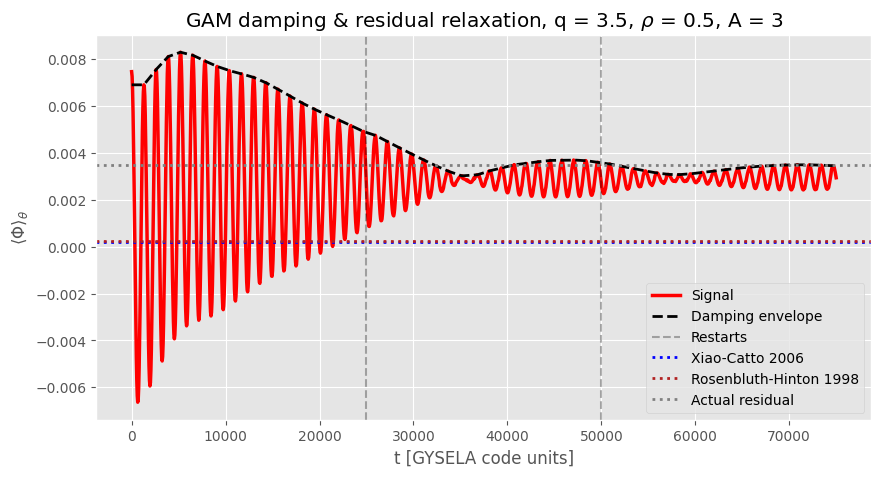

In [3]:
from scipy import signal;
from scipy.interpolate import interp1d;

def generate_damping_envelope(time_series, frequency, dt_diag):

	# The GAM period is first converted into diagonostic time-steps (corresponding strictly to indices)...
	# and then halved for the peak-to-peak distance. We remain in index-space always, not time-steps.
	minimum_distance = 0.5 * (1 / frequency) * (1 / dt_diag);
	peak_indices, _ = signal.find_peaks(time_series, distance = minimum_distance);
	peaks = time_series[peak_indices];
	# This is so-called 'virtual' because it corresponds to the diagnostic time-scale (by which Phi2D files are sampled).
	# Interpolation is agnostic as to whether we cast our time series in actual simulation time-steps or otherwise.
	virtual_peak_times = np.arange(len(time_series));
	envelope = interp1d(peak_indices, peaks, kind = "linear", bounds_error = False, fill_value = (peaks[0], peaks[-1]))(virtual_peak_times);
	return envelope;

def plot_rosenbluth_hinton(phi2D_list, dt_diag, jacobian_dictionary, aspect_ratio, safety_factor, title_suffix = "", effective_radius = 0.7, residual_window = 100, signal_band_pass = True):
	
	# Signal isolation and data processing.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary, effective_radius);

	if signal_band_pass:
		radial_time_series = utils.butterworth_band_pass_filter(radial_time_series, dt_diag);

	# We recover the actual time in code units here (normalised to the ion cyclotron frequency).
	# This does not actually change the size of the array, only its spacing.
	time_range = gys_utils.generate_time_range_by_series(radial_time_series, dt_diag);
	GAM_frequency = utils.extract_gam_frequency(phi2D_list, dt_diag, jacobian_dictionary, effective_radius);
	amplitude_envelope = generate_damping_envelope(radial_time_series, GAM_frequency, dt_diag);
	initial_amplitude = max(amplitude_envelope);
	residual_level = utils.calculate_residual_level(amplitude_envelope, residual_window, use_heuristic_approach = True);
	residual_level_xc2006 = analytical.residual_XiaoCatto2006(1. / aspect_ratio, safety_factor, k_rho = 0.01) * initial_amplitude;
	residual_level_rh1998 = analytical.residual_RosenbluthHinton1998(1. / aspect_ratio, safety_factor) * initial_amplitude;

	if signal_band_pass:
		# Restore residual levels as the band-pass eliminates this information.
		radial_time_series += residual_level;
		amplitude_envelope += residual_level;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range, radial_time_series, color = "red", lw = 2.5, label = "Signal");
	plt.plot(time_range, amplitude_envelope, color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	gys_utils.plot_restart_times(plt.gca(), restart_times);
	plt.axhline(y = residual_level_xc2006, color = "blue", linestyle = ":", label = "Xiao-Catto 2006", lw = 2.0);
	plt.axhline(y = residual_level_rh1998, color = "firebrick", linestyle = ":", label = "Rosenbluth-Hinton 1998", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = "Actual residual", lw = 2.0);
	plt.xlabel("t [GYSELA code units]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.title(f"GAM damping & residual relaxation, q = 3.5, $\\rho$ = {effective_radius}, {title_suffix}");
	plt.legend(frameon = True, loc = "lower right");
	plt.show();

plot_rosenbluth_hinton(
	data_arrays, 
	dt_diag, 
	jacobian_dictionary,
	aspect_ratio, 
	safety_factor, 
	effective_radius = 0.5, 
	residual_window = 100, 
	title_suffix = "A = 3", 
	signal_band_pass = False);